# Big Data Analysis of Steam Game User Reviews
## Sentiment Analysis Using Apache Spark

This notebook contains two connected analyses:

1. **Full multilingual descriptive analysis:** Steam's `recommended` field is used as a recommendation-based sentiment indicator for all reviews.
2. **English review-text classification:** Review words are transformed with TF-IDF and classified with Logistic Regression using `recommended` as the target label.

The separation is important: an English tokenisation and stop-word pipeline should not be presented as a valid multilingual NLP model.

## 1. Environment setup

Run the installation cell once whenever Google Colab starts a new runtime. If PySpark is already installed, Colab may complete this step quickly.

In [ ]:
!pip -q install pyspark

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Change these two paths if your file is stored elsewhere.
CSV_FILE = "/content/drive/My Drive/Colab Notebooks/steam_reviews.csv"
RESULTS_PATH = "/content/drive/My Drive/Colab Notebooks/steam_results_improved"

# Modelling controls chosen to remain practical on a Colab runtime.
MODEL_ROWS_PER_CLASS = 300_000
MODEL_TRAIN_RATIO = 0.80
SEED = 42

# The performance comparison uses identical samples for Spark and Pandas.
BENCHMARK_SIZES = [100_000, 500_000]

## 2. Imports and Spark configuration

`local[*]` uses all CPU cores of one Colab virtual machine. This is parallel Spark processing in a cloud-hosted runtime, not proof of a multi-node cluster. The same DataFrame code can later be deployed to a managed Spark cluster.

In [ ]:
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.functions import vector_to_array

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SteamReviewSentimentAnalysisImproved")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "32")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
sns.set_theme(style="whitegrid")

print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)

Spark version: 4.0.3
Spark master: local[*]
Default parallelism: 2


## 3. Load the dataset with an explicit schema

The source columns are initially read as strings because the CSV contains quoted, multiline text. Required analytical columns are cast explicitly during transformation. This avoids relying on full-file type inference.

In [ ]:
source_columns = [
    "_c0", "app_id", "app_name", "review_id", "language", "review",
    "timestamp_created", "timestamp_updated", "recommended", "votes_helpful",
    "votes_funny", "weighted_vote_score", "comment_count", "steam_purchase",
    "received_for_free", "written_during_early_access", "author.steamid",
    "author.num_games_owned", "author.num_reviews", "author.playtime_forever",
    "author.playtime_last_two_weeks", "author.playtime_at_review", "author.last_played"
]

steam_schema = T.StructType([
    T.StructField(name, T.StringType(), True) for name in source_columns
])

load_start = time.perf_counter()
steam_raw = (
    spark.read
    .schema(steam_schema)
    .option("header", "true")
    .option("quote", '"')
    .option("escape", '"')
    .option("multiLine", "true")
    .option("mode", "PERMISSIVE")
    .csv(CSV_FILE)
)

# Trigger an action so the timing includes actual file scanning.
raw_count = steam_raw.count()
load_seconds = time.perf_counter() - load_start

print(f"Raw records: {raw_count:,}")
print(f"Load and count time: {load_seconds:.2f} seconds")
print("Input partitions:", steam_raw.rdd.getNumPartitions())
steam_raw.printSchema()

Raw records: 21,747,371
Load and count time: 143.80 seconds
Input partitions: 1
root
 |-- _c0: string (nullable = true)
 |-- app_id: string (nullable = true)
 |-- app_name: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- language: string (nullable = true)
 |-- review: string (nullable = true)
 |-- timestamp_created: string (nullable = true)
 |-- timestamp_updated: string (nullable = true)
 |-- recommended: string (nullable = true)
 |-- votes_helpful: string (nullable = true)
 |-- votes_funny: string (nullable = true)
 |-- weighted_vote_score: string (nullable = true)
 |-- comment_count: string (nullable = true)
 |-- steam_purchase: string (nullable = true)
 |-- received_for_free: string (nullable = true)
 |-- written_during_early_access: string (nullable = true)
 |-- author.steamid: string (nullable = true)
 |-- author.num_games_owned: string (nullable = true)
 |-- author.num_reviews: string (nullable = true)
 |-- author.playtime_forever: string (nullable = true)

## 4. Data cleaning, duplicate removal and eight-attribute transformation

`review_id` is retained temporarily to remove duplicated review records. It is then excluded so the final analytical DataFrame contains exactly eight transformed attributes.

In [ ]:
clean_start = time.perf_counter()

steam_selected = steam_raw.select(
    "review_id",
    "review",
    "recommended",
    "app_id",
    "app_name",
    "language",
    F.col("`author.playtime_forever`").alias("playtime_minutes"),
    "timestamp_created",
    "votes_helpful"
)

steam_valid = (
    steam_selected
    .filter(F.col("review_id").isNotNull() & (F.trim("review_id") != ""))
    .filter(F.col("review").isNotNull() & (F.trim("review") != ""))
    .filter(F.col("app_id").isNotNull() & (F.trim("app_id") != ""))
    .filter(F.col("app_name").isNotNull() & (F.trim("app_name") != ""))
    .filter(F.lower(F.trim("recommended")).isin("true", "false"))
)

valid_before_duplicates = steam_valid.count()
steam_deduplicated = steam_valid.dropDuplicates(["review_id"])
valid_after_duplicates = steam_deduplicated.count()
duplicate_count = valid_before_duplicates - valid_after_duplicates

steam_final = (
    steam_deduplicated
    .withColumn(
        "sentiment",
        F.when(F.lower(F.trim("recommended")) == "true", "Positive")
         .otherwise("Negative")
    )
    .withColumn("app_id", F.col("app_id").cast("long"))
    .withColumn(
        "playtime_hours",
        F.round(F.col("playtime_minutes").cast("double") / F.lit(60.0), 2)
    )
    .withColumn("helpful_votes", F.col("votes_helpful").cast("long"))
    .withColumn(
        "review_timestamp",
        F.from_unixtime(F.col("timestamp_created").cast("long")).cast("timestamp")
    )
    .select(
        "review", "sentiment", "app_id", "app_name", "language",
        "playtime_hours", "review_timestamp", "helpful_votes"
    )
    .filter(F.col("app_id").isNotNull())
    .cache()
)

clean_count = steam_final.count()
clean_seconds = time.perf_counter() - clean_start

print(f"Valid records before duplicate removal: {valid_before_duplicates:,}")
print(f"Duplicate review IDs removed: {duplicate_count:,}")
print(f"Final clean records: {clean_count:,}")
print(f"Total records removed from raw data: {raw_count - clean_count:,}")
print(f"Retention rate: {clean_count / raw_count * 100:.2f}%")
print(f"Cleaning time: {clean_seconds:.2f} seconds")
print("Cleaned partitions:", steam_final.rdd.getNumPartitions())
print("Final number of attributes:", len(steam_final.columns))
steam_final.printSchema()
steam_final.show(5, truncate=80, vertical=True)

Valid records before duplicate removal: 21,712,901
Duplicate review IDs removed: 134,754
Final clean records: 21,578,147
Total records removed from raw data: 169,224
Retention rate: 99.22%
Cleaning time: 881.70 seconds
Cleaned partitions: 32
Final number of attributes: 8
root
 |-- review: string (nullable = true)
 |-- sentiment: string (nullable = false)
 |-- app_id: long (nullable = true)
 |-- app_name: string (nullable = true)
 |-- language: string (nullable = true)
 |-- playtime_hours: double (nullable = true)
 |-- review_timestamp: timestamp (nullable = true)
 |-- helpful_votes: long (nullable = true)

-RECORD 0--------------------------------------------------------------------------------------------
 review           | Legal pra carai jogar colocar uma radio e relaxar (DIrigindo e relaxando) que... 
 sentiment        | Positive                                                                         
 app_id           | 227300                                                      

## 5. Data-quality validation

Missing playtime is not removed from the whole project because such reviews still contain valid sentiment information. Rows with missing playtime are excluded only from analyses that require playtime.

In [ ]:
missing_values = steam_final.select([
    F.sum(F.col(c).isNull().cast("long")).alias(c)
    for c in steam_final.columns
])

print("Missing values after transformation:")
missing_values.show(vertical=True)

print("Timestamp range:")
steam_final.select(
    F.min("review_timestamp").alias("earliest_review"),
    F.max("review_timestamp").alias("latest_review")
).show(truncate=False)

print("Invalid negative values:")
steam_final.select(
    F.sum((F.col("playtime_hours") < 0).cast("long")).alias("negative_playtime"),
    F.sum((F.col("helpful_votes") < 0).cast("long")).alias("negative_helpful_votes")
).show()

Missing values after transformation:
-RECORD 0---------------
 review           | 0   
 sentiment        | 0   
 app_id           | 0   
 app_name         | 0   
 language         | 0   
 playtime_hours   | 2   
 review_timestamp | 0   
 helpful_votes    | 0   

Timestamp range:
+-------------------+-------------------+
|earliest_review    |latest_review      |
+-------------------+-------------------+
|2010-11-19 20:17:16|2021-01-23 18:24:47|
+-------------------+-------------------+

Invalid negative values:
+-----------------+----------------------+
|negative_playtime|negative_helpful_votes|
+-----------------+----------------------+
|                0|                     0|
+-----------------+----------------------+



## 6. Full multilingual recommendation-based sentiment analysis

This section uses `recommended` as a sentiment indicator. It does not claim to infer linguistic sentiment from every language.

+---------+-------------+----------+
|sentiment|total_reviews|percentage|
+---------+-------------+----------+
|Positive |18858629     |87.4      |
|Negative |2719518      |12.6      |
+---------+-------------+----------+



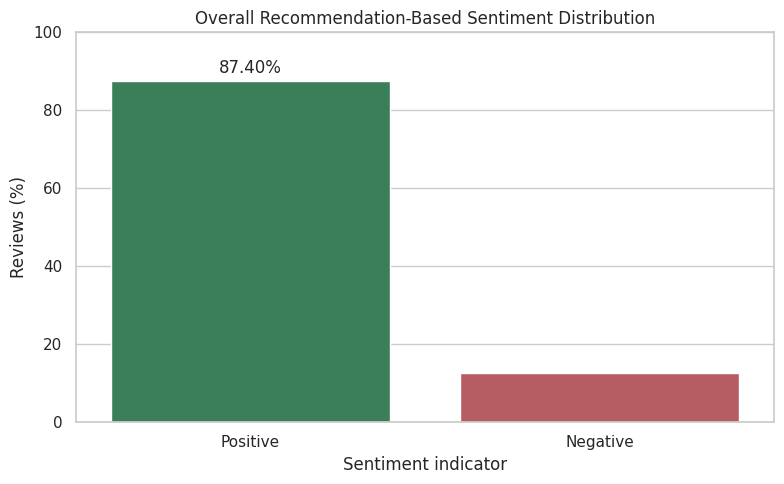

In [ ]:
sentiment_counts = steam_final.groupBy("sentiment").agg(
    F.count("*").alias("total_reviews")
)

sentiment_distribution = (
    sentiment_counts
    .withColumn(
        "percentage",
        F.round(F.col("total_reviews") / F.sum("total_reviews").over(Window.partitionBy()) * 100, 2)
    )
    .orderBy(F.desc("total_reviews"))
)

sentiment_distribution.show(truncate=False)

sentiment_pd = sentiment_distribution.toPandas()
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=sentiment_pd, x="sentiment", y="percentage", hue="sentiment",
    palette={"Positive": "#2E8B57", "Negative": "#C44E52"}, legend=False
)
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=3)
plt.title("Overall Recommendation-Based Sentiment Distribution")
plt.xlabel("Sentiment indicator")
plt.ylabel("Reviews (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
game_sentiment = (
    steam_final
    .groupBy("app_id", "app_name")
    .agg(
        F.count("*").alias("total_reviews"),
        F.sum(F.when(F.col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews"),
        F.sum(F.when(F.col("sentiment") == "Negative", 1).otherwise(0)).alias("negative_reviews")
    )
    .withColumn(
        "positive_rate_unrounded",
        F.col("positive_reviews").cast("double") / F.col("total_reviews").cast("double") * 100
    )
    .withColumn("positive_rate", F.round("positive_rate_unrounded", 2))
    .drop("positive_rate_unrounded")
    .cache()
)

top_reviewed_games = game_sentiment.orderBy(F.desc("total_reviews")).limit(10)
highest_positive_games = (
    game_sentiment.filter(F.col("total_reviews") >= 1000)
    .orderBy(F.desc("positive_rate"), F.desc("total_reviews")).limit(10)
)
lowest_positive_games = (
    game_sentiment.filter(F.col("total_reviews") >= 1000)
    .orderBy(F.asc("positive_rate"), F.desc("total_reviews")).limit(10)
)

print("Top 10 most-reviewed games")
top_reviewed_games.show(10, truncate=False)
print("Highest positive rates (minimum 1,000 reviews)")
highest_positive_games.show(10, truncate=False)
print("Lowest positive rates (minimum 1,000 reviews)")
lowest_positive_games.show(10, truncate=False)

Top 10 most-reviewed games
+------+------------------------------+-------------+----------------+----------------+-------------+
|app_id|app_name                      |total_reviews|positive_reviews|negative_reviews|positive_rate|
+------+------------------------------+-------------+----------------+----------------+-------------+
|578080|PLAYERUNKNOWN'S BATTLEGROUNDS |1643238      |885541          |757697          |53.89        |
|271590|Grand Theft Auto V            |1017299      |829556          |187743          |81.54        |
|359550|Tom Clancy's Rainbow Six Siege|840296       |740828          |99468           |88.16        |
|105600|Terraria                      |671742       |657675          |14067           |97.91        |
|4000  |Garry's Mod                   |654458       |631507          |22951           |96.49        |
|252490|Rust                          |548380       |468237          |80143           |85.39        |
|252950|Rocket League                 |497809       |44

## 7. Language and time analysis

Language results compare recommendation behaviour, not the linguistic accuracy of a multilingual sentiment model. Monthly trends are limited to games with sufficient review volume to avoid unstable percentages.

In [ ]:
language_sentiment = (
    steam_final
    .filter(F.col("language").isNotNull())
    .groupBy("language")
    .agg(
        F.count("*").alias("total_reviews"),
        F.sum(F.when(F.col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews"),
        F.sum(F.when(F.col("sentiment") == "Negative", 1).otherwise(0)).alias("negative_reviews")
    )
    .withColumn("positive_rate", F.round(F.col("positive_reviews") / F.col("total_reviews") * 100, 2))
    .orderBy(F.desc("total_reviews"))
)

yearly_sentiment = (
    steam_final.filter(F.col("review_timestamp").isNotNull())
    .withColumn("review_year", F.year("review_timestamp"))
    .groupBy("review_year")
    .agg(
        F.count("*").alias("total_reviews"),
        F.sum(F.when(F.col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews")
    )
    .withColumn("negative_reviews", F.col("total_reviews") - F.col("positive_reviews"))
    .withColumn("positive_rate", F.round(F.col("positive_reviews") / F.col("total_reviews") * 100, 2))
    .orderBy("review_year")
)

monthly_game_sentiment = (
    steam_final.filter(F.col("review_timestamp").isNotNull())
    .withColumn("review_month", F.date_format("review_timestamp", "yyyy-MM"))
    .groupBy("app_id", "app_name", "review_month")
    .agg(
        F.count("*").alias("total_reviews"),
        F.sum(F.when(F.col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews")
    )
    .filter(F.col("total_reviews") >= 100)
    .withColumn("positive_rate", F.round(F.col("positive_reviews") / F.col("total_reviews") * 100, 2))
)

language_sentiment.show(20, truncate=False)
yearly_sentiment.show(50, truncate=False)
monthly_game_sentiment.orderBy(F.desc("total_reviews")).show(20, truncate=False)

+----------+-------------+----------------+----------------+-------------+
|language  |total_reviews|positive_reviews|negative_reviews|positive_rate|
+----------+-------------+----------------+----------------+-------------+
|english   |9563631      |8514767         |1048864         |89.03        |
|schinese  |3726392      |2866090         |860302          |76.91        |
|russian   |2338073      |2084960         |253113          |89.17        |
|brazilian |826256       |779482          |46774           |94.34        |
|spanish   |803639       |745353          |58286           |92.75        |
|german    |749038       |662772          |86266           |88.48        |
|turkish   |633555       |571776          |61779           |90.25        |
|koreana   |608200       |511502          |96698           |84.1         |
|french    |537274       |485995          |51279           |90.46        |
|polish    |493033       |466212          |26821           |94.56        |
|tchinese  |216115       

## 8. Playtime and review-helpfulness analysis

Median values are reported alongside means because playtime and helpful-vote distributions can be highly skewed.

In [ ]:
playtime_data = (
    steam_final
    .filter(F.col("playtime_hours").isNotNull() & (F.col("playtime_hours") >= 0))
    .withColumn(
        "playtime_group",
        F.when(F.col("playtime_hours") < 1, "1. Less than 1 hour")
         .when(F.col("playtime_hours") < 10, "2. 1-9 hours")
         .when(F.col("playtime_hours") < 50, "3. 10-49 hours")
         .when(F.col("playtime_hours") < 100, "4. 50-99 hours")
         .otherwise("5. 100 hours or more")
    )
)

playtime_sentiment = (
    playtime_data.groupBy("playtime_group")
    .agg(
        F.count("*").alias("total_reviews"),
        F.sum(F.when(F.col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews"),
        F.round(F.avg("playtime_hours"), 2).alias("mean_playtime_hours"),
        F.round(F.expr("percentile_approx(playtime_hours, 0.5)"), 2).alias("median_playtime_hours")
    )
    .withColumn("negative_reviews", F.col("total_reviews") - F.col("positive_reviews"))
    .withColumn("positive_rate", F.round(F.col("positive_reviews") / F.col("total_reviews") * 100, 2))
    .orderBy("playtime_group")
)

helpfulness_by_sentiment = (
    steam_final.filter(F.col("helpful_votes").isNotNull() & (F.col("helpful_votes") >= 0))
    .groupBy("sentiment")
    .agg(
        F.count("*").alias("total_reviews"),
        F.round(F.avg("helpful_votes"), 2).alias("mean_helpful_votes"),
        F.expr("percentile_approx(helpful_votes, 0.5)").alias("median_helpful_votes"),
        F.sum(F.when(F.col("helpful_votes") > 0, 1).otherwise(0)).alias("reviews_with_helpful_vote")
    )
    .withColumn(
        "helpful_vote_rate",
        F.round(F.col("reviews_with_helpful_vote") / F.col("total_reviews") * 100, 2)
    )
)

playtime_sentiment.show(truncate=False)
helpfulness_by_sentiment.show(truncate=False)

+--------------------+-------------+----------------+-------------------+---------------------+----------------+-------------+
|playtime_group      |total_reviews|positive_reviews|mean_playtime_hours|median_playtime_hours|negative_reviews|positive_rate|
+--------------------+-------------+----------------+-------------------+---------------------+----------------+-------------+
|1. Less than 1 hour |363214       |196955          |0.52               |0.52                 |166259          |54.23        |
|2. 1-9 hours        |2583554      |2134952         |5.38               |5.33                 |448602          |82.64        |
|3. 10-49 hours      |6157657      |5594811         |26.28              |24.42                |562846          |90.86        |
|4. 50-99 hours      |3185424      |2907142         |72.08              |70.65                |278282          |91.26        |
|5. 100 hours or more|9288296      |8024767         |582.44             |307.53               |1263529         

## 9. Spark SQL analysis

The cleaned DataFrame is registered as a temporary SQL view. These queries add analyses rather than merely repeating every DataFrame result.

In [ ]:
steam_final.createOrReplaceTempView("steam_reviews")

sql_game_sentiment = spark.sql("""
SELECT
    app_id,
    app_name,
    COUNT(*) AS total_reviews,
    SUM(CASE WHEN sentiment = 'Positive' THEN 1 ELSE 0 END) AS positive_reviews,
    SUM(CASE WHEN sentiment = 'Negative' THEN 1 ELSE 0 END) AS negative_reviews,
    ROUND(100.0 * SUM(CASE WHEN sentiment = 'Positive' THEN 1 ELSE 0 END) / COUNT(*), 2) AS positive_rate
FROM steam_reviews
GROUP BY app_id, app_name
HAVING COUNT(*) >= 1000
ORDER BY total_reviews DESC
LIMIT 10
""")

sql_helpfulness = spark.sql("""
SELECT
    sentiment,
    COUNT(*) AS total_reviews,
    ROUND(AVG(helpful_votes), 2) AS mean_helpful_votes,
    PERCENTILE_APPROX(helpful_votes, 0.5) AS median_helpful_votes,
    ROUND(100.0 * SUM(CASE WHEN helpful_votes > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS helpful_vote_rate
FROM steam_reviews
WHERE helpful_votes IS NOT NULL AND helpful_votes >= 0
GROUP BY sentiment
ORDER BY sentiment
""")

sql_negative_games = spark.sql("""
SELECT
    app_name,
    COUNT(*) AS total_reviews,
    SUM(CASE WHEN sentiment = 'Negative' THEN 1 ELSE 0 END) AS negative_reviews,
    ROUND(100.0 * SUM(CASE WHEN sentiment = 'Negative' THEN 1 ELSE 0 END) / COUNT(*), 2) AS negative_rate
FROM steam_reviews
GROUP BY app_name
HAVING COUNT(*) >= 1000
ORDER BY negative_reviews DESC
LIMIT 10
""")

sql_game_sentiment.show(10, truncate=False)
sql_helpfulness.show(truncate=False)
sql_negative_games.show(10, truncate=False)

+------+------------------------------+-------------+----------------+----------------+-------------+
|app_id|app_name                      |total_reviews|positive_reviews|negative_reviews|positive_rate|
+------+------------------------------+-------------+----------------+----------------+-------------+
|578080|PLAYERUNKNOWN'S BATTLEGROUNDS |1643238      |885541          |757697          |53.89        |
|271590|Grand Theft Auto V            |1017299      |829556          |187743          |81.54        |
|359550|Tom Clancy's Rainbow Six Siege|840296       |740828          |99468           |88.16        |
|105600|Terraria                      |671742       |657675          |14067           |97.91        |
|4000  |Garry's Mod                   |654458       |631507          |22951           |96.49        |
|252490|Rust                          |548380       |468237          |80143           |85.39        |
|252950|Rocket League                 |497809       |448741          |49068       

## 10. Physical execution plan

The formatted plan provides implementation evidence of scanning, filtering, partial aggregation, shuffle exchange and final aggregation. The exact plan may vary by Spark version.

In [ ]:
game_sentiment.explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (39)
+- InMemoryTableScan (1)
      +- InMemoryRelation (2)
            +- AdaptiveSparkPlan (38)
               +- == Final Plan ==
                  ResultQueryStage (33)
                  +- * Project (32)
                     +- * HashAggregate (31)
                        +- ShuffleQueryStage (30), Statistics(sizeInBytes=674.5 KiB, rowCount=1.01E+4)
                           +- Exchange (29)
                              +- * HashAggregate (28)
                                 +- TableCacheQueryStage (27), Statistics(sizeInBytes=5.8 GiB, rowCount=2.16E+7)
                                    +- InMemoryTableScan (3)
                                          +- InMemoryRelation (4)
                                                +- AdaptiveSparkPlan (26)
                                 +- == Final Plan ==
                                    ResultQueryStage (16)
                                    +- * Project (15)
                            

## 11. English review-text sentiment classification

`recommended` becomes the numerical target label only. It is **not** included in the TF-IDF input features, which prevents target leakage.

To keep training practical on Colab, the notebook takes an approximately balanced stratified sample of up to `MODEL_ROWS_PER_CLASS` English reviews from each class. The reported metrics therefore evaluate text classification on this modelling sample, not the natural 87:13 distribution of the entire dataset.

In [ ]:
english_labeled = (
    steam_final
    .filter((F.col("language") == "english") & F.col("review").isNotNull())
    .select(
        "review",
        F.when(F.col("sentiment") == "Positive", F.lit(1.0)).otherwise(F.lit(0.0)).alias("label")
    )
    .cache()
)

english_class_counts = {
    float(row["label"]): int(row["count"])
    for row in english_labeled.groupBy("label").count().collect()
}

fractions = {
    label: min(1.0, MODEL_ROWS_PER_CLASS / count)
    for label, count in english_class_counts.items()
}

model_data = english_labeled.sampleBy("label", fractions=fractions, seed=SEED).cache()

print("Full English class distribution:", english_class_counts)
print("Sampling fractions:", fractions)
model_data.groupBy("label").count().orderBy("label").show()

train_data, test_data = model_data.randomSplit(
    [MODEL_TRAIN_RATIO, 1.0 - MODEL_TRAIN_RATIO], seed=SEED
)
train_data = train_data.cache()
test_data = test_data.cache()

print(f"Training rows: {train_data.count():,}")
print(f"Testing rows: {test_data.count():,}")

Full English class distribution: {1.0: 8514767, 0.0: 1048864}
Sampling fractions: {1.0: 0.0352329077237228, 0.0: 0.28602373615645116}
+-----+------+
|label| count|
+-----+------+
|  0.0|300296|
|  1.0|299472|
+-----+------+

Training rows: 479,624
Testing rows: 120,144


In [ ]:
tokenizer = RegexTokenizer(
    inputCol="review",
    outputCol="tokens",
    pattern="[^A-Za-z']+",
    minTokenLength=2,
    toLowercase=True
)

stopword_remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens",
    caseSensitive=False
)

hashing_tf = HashingTF(
    inputCol="filtered_tokens",
    outputCol="raw_features",
    numFeatures=1 << 18
)

idf = IDF(
    inputCol="raw_features",
    outputCol="features",
    minDocFreq=5
)

logistic_regression = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=30,
    regParam=0.01,
    elasticNetParam=0.0
)

sentiment_pipeline = Pipeline(stages=[
    tokenizer,
    stopword_remover,
    hashing_tf,
    idf,
    logistic_regression
])

model_start = time.perf_counter()
sentiment_model = sentiment_pipeline.fit(train_data)
predictions = sentiment_model.transform(test_data).cache()
prediction_count = predictions.count()
model_seconds = time.perf_counter() - model_start

print(f"Predictions generated: {prediction_count:,}")
print(f"Model training and prediction time: {model_seconds:.2f} seconds")

Predictions generated: 120,144
Model training and prediction time: 130.03 seconds


## 12. Model evaluation

Accuracy alone is insufficient for an imbalanced classification problem. Precision, recall, F1, ROC-AUC and the confusion matrix are therefore reported together.

Accuracy: 0.8420
Weighted precision: 0.8458
Weighted recall: 0.8420
F1-score: 0.8416
ROC-AUC: 0.9111
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|47276|
|  0.0|       1.0|12629|
|  1.0|       0.0| 6348|
|  1.0|       1.0|53891|
+-----+----------+-----+



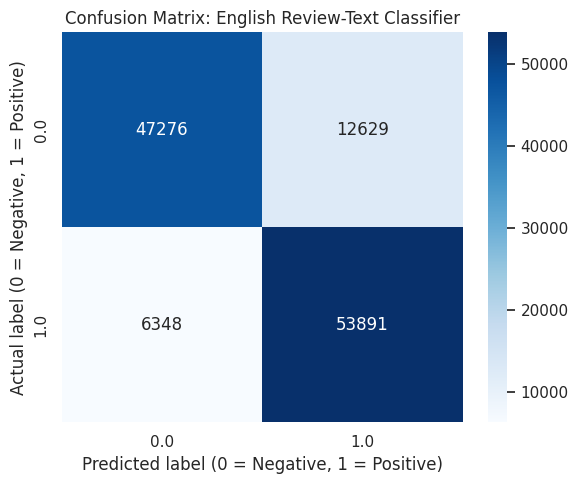

In [ ]:
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
)
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

metrics = {
    "Accuracy": accuracy_evaluator.evaluate(predictions),
    "Weighted precision": precision_evaluator.evaluate(predictions),
    "Weighted recall": recall_evaluator.evaluate(predictions),
    "F1-score": f1_evaluator.evaluate(predictions),
    "ROC-AUC": auc_evaluator.evaluate(predictions)
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

confusion_matrix = (
    predictions.groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)
confusion_matrix.show()

cm_pd = confusion_matrix.toPandas().pivot(
    index="label", columns="prediction", values="count"
).fillna(0)
cm_pd = cm_pd.reindex(index=[0.0, 1.0], columns=[0.0, 1.0], fill_value=0)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pd, annot=True, fmt=".0f", cmap="Blues")
plt.title("Confusion Matrix: English Review-Text Classifier")
plt.xlabel("Predicted label (0 = Negative, 1 = Positive)")
plt.ylabel("Actual label (0 = Negative, 1 = Positive)")
plt.tight_layout()
plt.show()

In [ ]:
print("Example text predictions:")
(
    predictions
    .select(
        F.substring("review", 1, 160).alias("review_excerpt"),
        "label",
        "prediction",
        F.round(vector_to_array("probability")[1], 4).alias("positive_probability")
    )
    .show(20, truncate=False)
)

Example text predictions:
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+--------------------+
|review_excerpt                                                                                                                                                     |label|prediction|positive_probability|
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+--------------------+
|\n\nI am a Jedi Battle Royale survival game player, all before the game has never written comments. But I'm really sad today. After the latest big update, the gam |0.0  |0.0       |0.0067              |
|\nFaced an issue in playing co-op with my brother.\nIt's close to unreal to connect each other.\nWe had to "farm" connect button in average from 1 to 3 hours

## 13. Spark versus Pandas performance comparison

This is a controlled aggregation benchmark, not a claim that Spark is always faster. The same rows and same sentiment-counting task are used. Spark may be slower for smaller samples because session scheduling and distributed execution introduce overhead. Its advantage is scalability beyond a single-machine DataFrame.

In [ ]:
benchmark_results = []

# Keep only the columns needed by the comparison.
benchmark_source = steam_final.select("sentiment").cache()
benchmark_source.count()

for requested_size in BENCHMARK_SIZES:
    sample_spark = benchmark_source.limit(requested_size).cache()
    actual_size = sample_spark.count()

    spark_start = time.perf_counter()
    spark_result = sample_spark.groupBy("sentiment").count().collect()
    spark_seconds = time.perf_counter() - spark_start

    # Materialisation is deliberately outside the Pandas aggregation timer.
    # Report collection time separately because transfer to the driver is a real cost.
    collect_start = time.perf_counter()
    sample_pandas = sample_spark.toPandas()
    collect_seconds = time.perf_counter() - collect_start

    pandas_start = time.perf_counter()
    pandas_result = sample_pandas.groupby("sentiment").size()
    pandas_seconds = time.perf_counter() - pandas_start

    benchmark_results.append({
        "rows": actual_size,
        "spark_aggregation_seconds": spark_seconds,
        "collect_to_driver_seconds": collect_seconds,
        "pandas_aggregation_seconds": pandas_seconds,
        "spark_counts": {row["sentiment"]: row["count"] for row in spark_result},
        "pandas_counts": pandas_result.to_dict(),
        "outputs_match": {row["sentiment"]: row["count"] for row in spark_result} == pandas_result.to_dict()
    })

    sample_spark.unpersist()

benchmark_pd = pd.DataFrame(benchmark_results)
benchmark_pd[[
    "rows", "spark_aggregation_seconds", "collect_to_driver_seconds",
    "pandas_aggregation_seconds", "outputs_match"
]]

,rows,spark_aggregation_seconds,collect_to_driver_seconds,pandas_aggregation_seconds,outputs_match
0,100000,0.529316,1.576123,0.020222,True
1,500000,0.328539,4.972781,0.044892,True


## 14. Save aggregated outputs

`coalesce(1)` is used only for small summary tables. Large detailed DataFrames should remain partitioned when written.

In [ ]:
outputs = {
    "sentiment_distribution": sentiment_distribution,
    "top_reviewed_games": top_reviewed_games,
    "highest_positive_games": highest_positive_games,
    "lowest_positive_games": lowest_positive_games,
    "language_sentiment": language_sentiment,
    "yearly_sentiment": yearly_sentiment,
    "monthly_game_sentiment": monthly_game_sentiment,
    "playtime_sentiment": playtime_sentiment,
    "helpfulness_by_sentiment": helpfulness_by_sentiment,
    "model_confusion_matrix": confusion_matrix
}

for output_name, output_df in outputs.items():
    (
        output_df.coalesce(1)
        .write.mode("overwrite")
        .option("header", "true")
        .csv(f"{RESULTS_PATH}/{output_name}")
    )

benchmark_pd.to_csv(f"{RESULTS_PATH}/spark_pandas_benchmark.csv", index=False)

print("Analysis completed.")
print("Results saved to:", RESULTS_PATH)

Analysis completed.
Results saved to: /content/drive/My Drive/Colab Notebooks/steam_results_improved


## 15. Visualization Implementation:

The charts are formed using the results above for better visual aids in Analysis of Output.


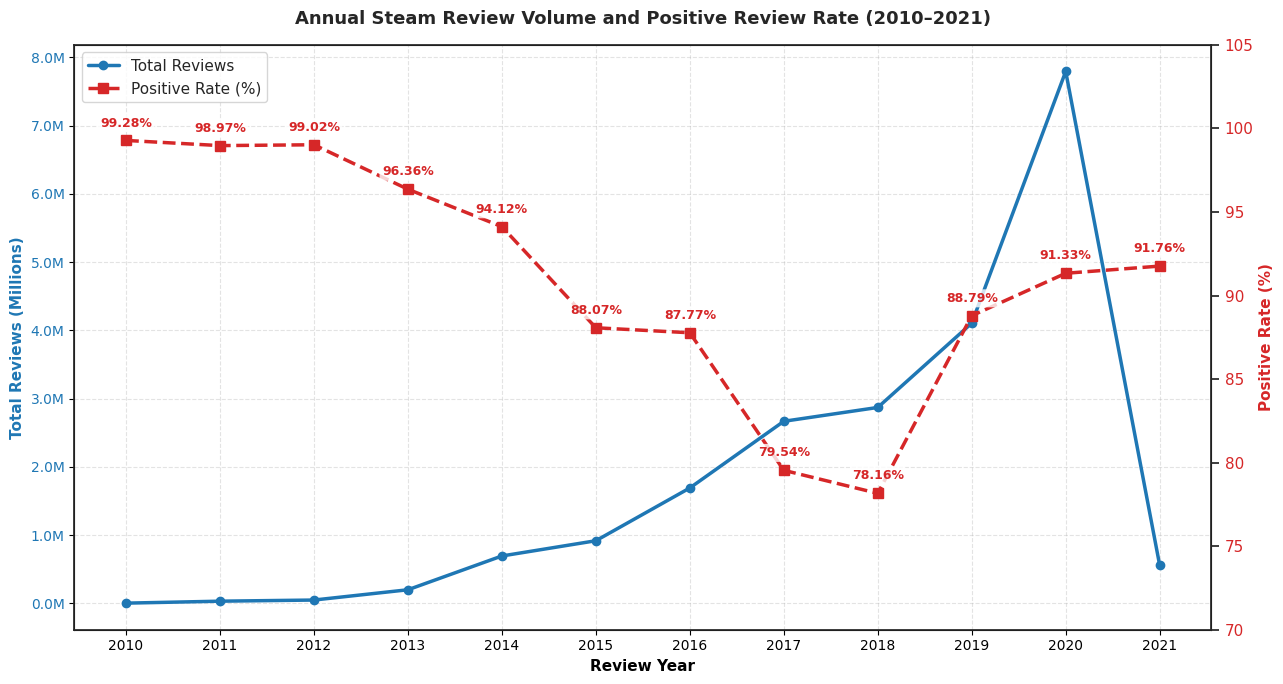

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns

# 1. Dataset
data = {
    "review_year": [
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    "total_reviews": [
        2370,
        30991,
        47705,
        198296,
        693554,
        916977,
        1690473,
        2667680,
        2870569,
        4105969,
        7795979,
        557584,
    ],
    "positive_rate": [
        99.28,
        98.97,
        99.02,
        96.36,
        94.12,
        88.07,
        87.77,
        79.54,
        78.16,
        88.79,
        91.33,
        91.76,
    ],
}

df = pd.DataFrame(data)

# 2. Setup Figure & Dual Axes
fig, ax1 = plt.subplots(figsize=(13, 7))
sns.set_theme(style="white")

COLOR_VOL = "#1f77b4"  # Blue for Volume
COLOR_RATE = "#d62728"  # Red for Sentiment

# Left Axis: Total Reviews Line
line1 = ax1.plot(
    df["review_year"],
    df["total_reviews"],
    color=COLOR_VOL,
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Total Reviews",
)
ax1.set_xlabel("Review Year", fontsize=11, fontweight="bold")
ax1.set_ylabel(
    "Total Reviews (Millions)", color=COLOR_VOL, fontsize=11, fontweight="bold"
)
ax1.tick_params(axis="y", labelcolor=COLOR_VOL)
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x*1e-6:.1f}M")
)
ax1.grid(True, linestyle="--", alpha=0.35)

# Right Axis: Positive Rate Line
ax2 = ax1.twinx()
line2 = ax2.plot(
    df["review_year"],
    df["positive_rate"],
    color=COLOR_RATE,
    linewidth=2.5,
    linestyle="--",
    marker="s",
    markersize=7,
    label="Positive Rate (%)",
)
ax2.set_ylabel(
    "Positive Rate (%)", color=COLOR_RATE, fontsize=11, fontweight="bold"
)
ax2.tick_params(axis="y", labelcolor=COLOR_RATE)
ax2.set_ylim(70, 105)

# 3. Add Exact Number Labels for Positive Rate
for _, row in df.iterrows():
    ax2.annotate(
        f"{row['positive_rate']:.2f}%",
        (row["review_year"], row["positive_rate"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=COLOR_RATE,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none")
    )

# 4. Titles & Formatting
plt.title(
    "Annual Steam Review Volume and Positive Review Rate (2010–2021)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax1.set_xticks(df["review_year"])

# Combine Legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

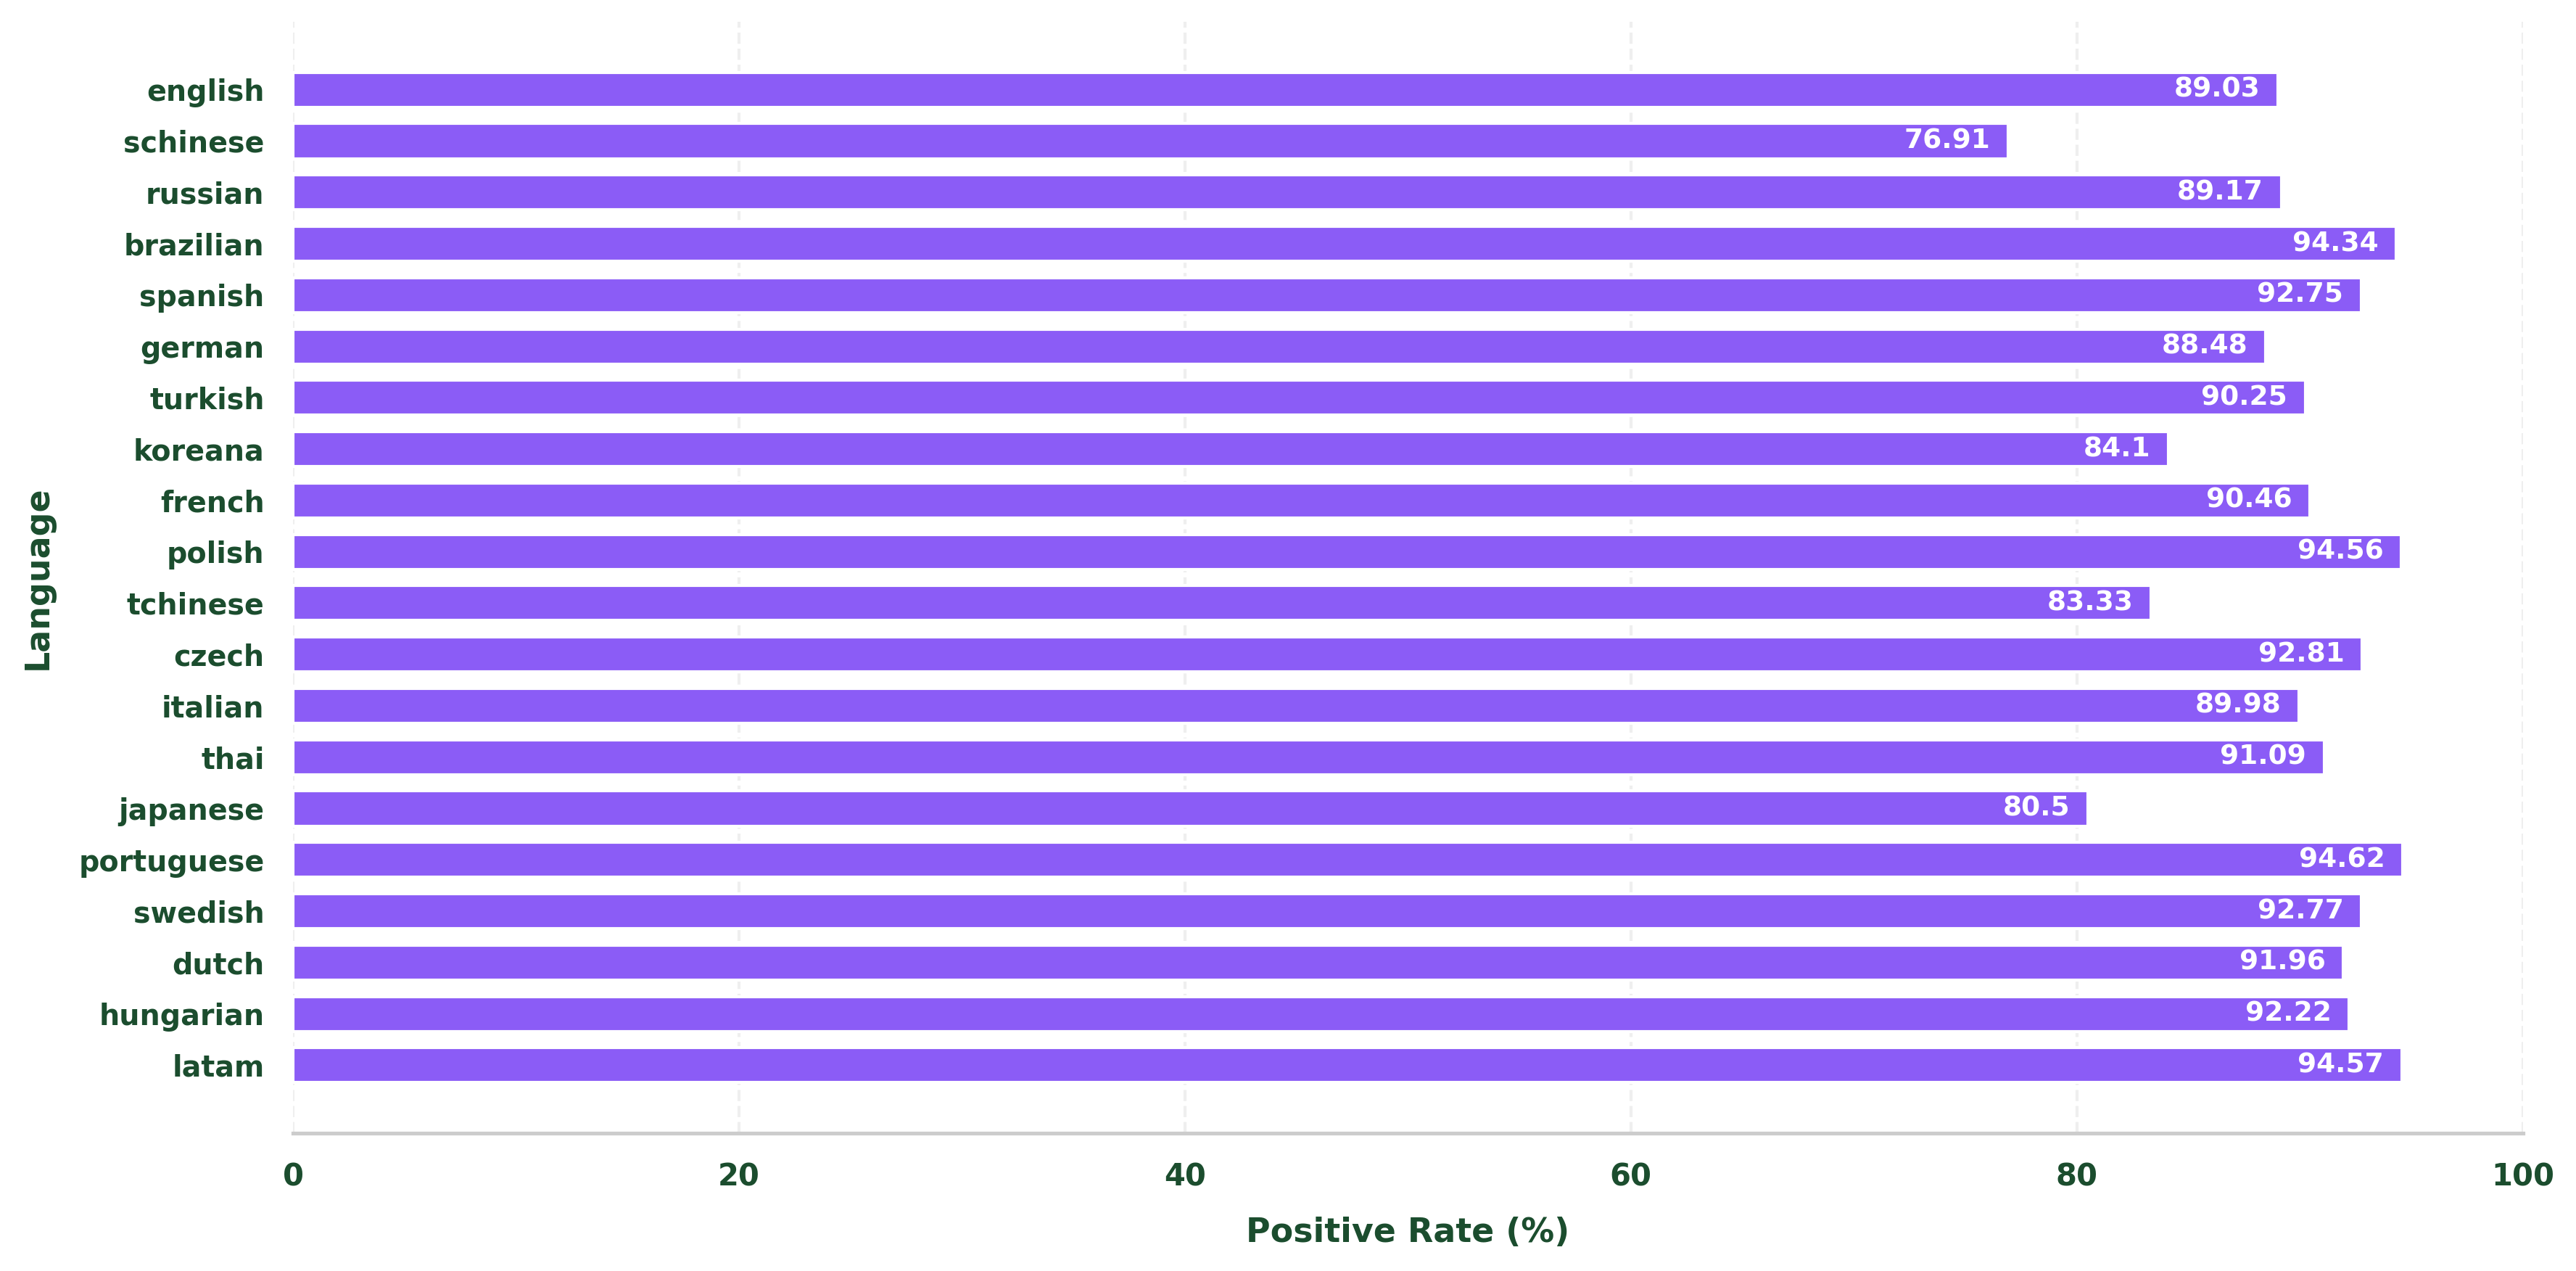

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Dataset in the exact order shown in the image
data = {
    "language": [
        "english", "schinese", "russian", "brazilian", "spanish",
        "german", "turkish", "koreana", "french", "polish",
        "tchinese", "czech", "italian", "thai", "japanese",
        "portuguese", "swedish", "dutch", "hungarian", "latam"
    ],
    "positive_rate": [
        89.03, 76.91, 89.17, 94.34, 92.75,
        88.48, 90.25, 84.1, 90.46, 94.56,
        83.33, 92.81, 89.98, 91.09, 80.5,
        94.62, 92.77, 91.96, 92.22, 94.57
    ]
}

df = pd.DataFrame(data)

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Colors matching the image
BAR_COLOR = "#8B5CF6"       # Vivid purple
TEXT_COLOR = "#1B4D2E"      # Dark green for axis labels and ticks

# Invert y-axis so 'english' is on top
y_positions = range(len(df))

# 3. Create Horizontal Bars
bars = ax.barh(
    y_positions,
    df["positive_rate"],
    height=0.68,
    color=BAR_COLOR,
    align='center'
)

# 4. Add Value Labels at the end of each bar
for bar, value in zip(bars, df["positive_rate"]):
    width = bar.get_width()
    ax.text(
        width - 0.8,                     # Position just inside the bar edge
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        ha='right',
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

# 5. Axes & Styling
ax.set_yticks(list(y_positions))
ax.set_yticklabels(df["language"], fontsize=9.5, fontweight='bold', color=TEXT_COLOR)
ax.invert_yaxis()  # Top-down order

# X-axis setup (0 to 100)
ax.set_xlim(0, 100)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels([0, 20, 40, 60, 80, 100], fontsize=10, fontweight='bold', color=TEXT_COLOR)

# Axis Titles
ax.set_xlabel("Positive Rate (%)", fontsize=11, fontweight='bold', color=TEXT_COLOR, labelpad=8)
ax.set_ylabel("Language", fontsize=11, fontweight='bold', color=TEXT_COLOR, labelpad=8)

# Gridlines & Spines
ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)

# Clean borders (remove top, right, and left spines)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.show()

<Figure size 1100x600 with 0 Axes>

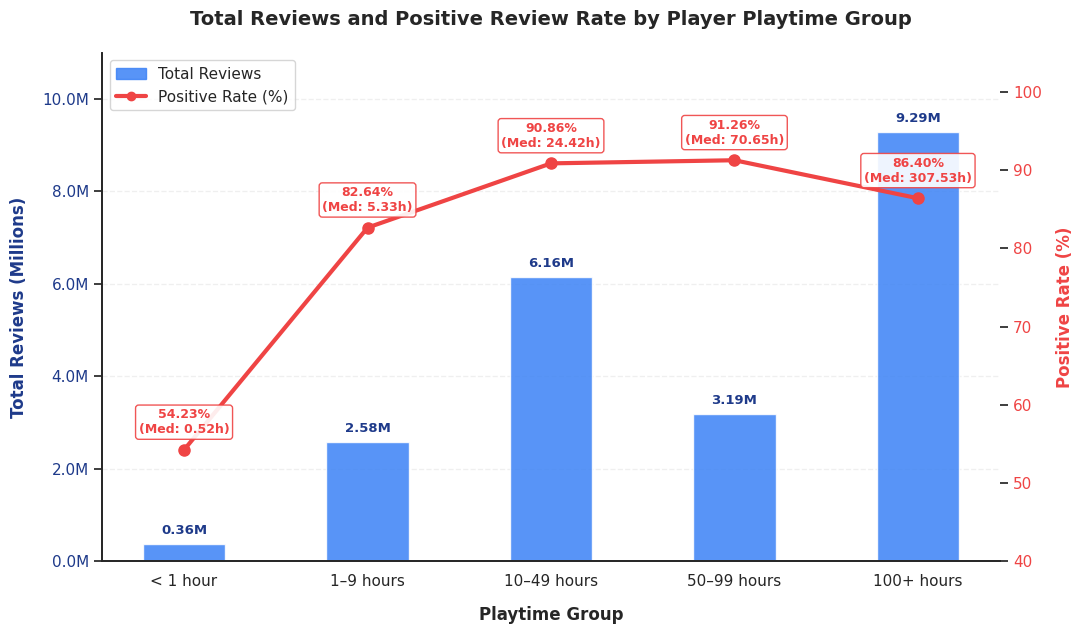

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns

# 1. Dataset
data = {
    "playtime_group": [
        "< 1 hour",
        "1–9 hours",
        "10–49 hours",
        "50–99 hours",
        "100+ hours",
    ],
    "total_reviews": [363214, 2583554, 6157657, 3185424, 9288296],
    "median_playtime": [0.52, 5.33, 24.42, 70.65, 307.53],
    "positive_rate": [54.23, 82.64, 90.86, 91.26, 86.40],
}

df = pd.DataFrame(data)

# 2. Figure Setup
plt.figure(figsize=(11, 6))
sns.set_theme(style="white")

fig, ax1 = plt.subplots(figsize=(11, 6.5))

# 3. Bar Chart: Total Reviews (Volume)
BAR_COLOR = "#3B82F6"  # Royal Blue
bars = ax1.bar(
    df["playtime_group"],
    df["total_reviews"],
    color=BAR_COLOR,
    width=0.45,
    alpha=0.85,
    label="Total Reviews",
)

ax1.set_xlabel("Playtime Group", fontsize=12, fontweight="bold", labelpad=12)
ax1.set_ylabel(
    "Total Reviews (Millions)",
    color="#1E3A8A",
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)
ax1.tick_params(axis="y", labelcolor="#1E3A8A")
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x*1e-6:.1f}M")
)
ax1.set_ylim(0, 11000000)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Add volume labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 150000,
        f"{height*1e-6:.2f}M",
        ha="center",
        va="bottom",
        fontsize=9.5,
        fontweight="bold",
        color="#1E3A8A",
    )

# 4. Line Chart: Positive Sentiment Rate (%)
ax2 = ax1.twinx()
LINE_COLOR = "#EF4444"  # Vibrant Red
line = ax2.plot(
    df["playtime_group"],
    df["positive_rate"],
    color=LINE_COLOR,
    linewidth=3,
    marker="o",
    markersize=8,
    label="Positive Rate (%)",
)

ax2.set_ylabel(
    "Positive Rate (%)",
    color=LINE_COLOR,
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)
ax2.tick_params(axis="y", labelcolor=LINE_COLOR)
ax2.set_ylim(40, 105)

# Add exact percentage callouts above line points
for idx, row in df.iterrows():
    ax2.annotate(
        f"{row['positive_rate']:.2f}%\n(Med: {row['median_playtime']}h)",
        (row["playtime_group"], row["positive_rate"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=LINE_COLOR,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=LINE_COLOR,
            alpha=0.9,
            linewidth=1,
        ),
    )

# 5. Header and Legend
plt.title(
    "Total Reviews and Positive Review Rate by Player Playtime Group",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Combined Legend
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=BAR_COLOR, alpha=0.85, label="Total Reviews"),
    plt.Line2D(
        [0],
        [0],
        color=LINE_COLOR,
        lw=3,
        marker="o",
        label="Positive Rate (%)",
    ),
]
ax1.legend(handles=legend_elements, loc="upper left", frameon=True)

sns.despine(top=True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Dataset
data = {
    "game": [
        "Among Us",
        "Among Us",
        "PUBG",
        "PUBG",
        "PUBG",
        "Among Us",
        "PUBG",
        "Phasmophobia",
        "PUBG",
        "Tom Clancy's Rainbow Six Siege",
        "Phasmophobia",
        "Grand Theft Auto V",
        "PUBG",
        "PUBG",
        "Grand Theft Auto V",
        "Terraria",
        "Grand Theft Auto V",
        "No Man's Sky",
        "Monster Hunter: World",
        "PUBG",
    ],
    "review_month": [
        "2020-09",
        "2020-10",
        "2017-11",
        "2019-11",
        "2017-10",
        "2020-11",
        "2017-12",
        "2020-11",
        "2019-12",
        "2019-11",
        "2020-10",
        "2019-11",
        "2018-01",
        "2020-01",
        "2019-12",
        "2020-05",
        "2017-06",
        "2016-08",
        "2018-08",
        "2017-09",
    ],
    "total_reviews": [
        149331,
        140675,
        122983,
        119358,
        104243,
        100236,
        90981,
        90209,
        74966,
        70956,
        70152,
        65079,
        63783,
        57649,
        57300,
        57133,
        56302,
        53275,
        53140,
        52800,
    ],
    "positive_rate": [
        95.40,
        96.27,
        67.35,
        65.53,
        36.74,
        96.16,
        44.85,
        98.36,
        60.04,
        94.35,
        96.95,
        92.02,
        50.21,
        59.24,
        91.92,
        97.76,
        25.59,
        47.01,
        58.56,
        58.91,
    ],
}

df = pd.DataFrame(data)

# Create clean display label: "Game Name (YYYY-MM)"
df["event"] = df["game"] + " (" + df["review_month"] + ")"
df = df.sort_values(by="total_reviews", ascending=True).reset_index(drop=True)

# 2. Setup Plot & Colormap
plt.figure(figsize=(13, 9))
sns.set_theme(style="whitegrid")

# Colormap: Red (Low sentiment) -> Yellow -> Green (High sentiment)
norm = plt.Normalize(vmin=20, vmax=100)
cmap = plt.colormaps.get_cmap("RdYlGn") # Updated to address MatplotlibDeprecationWarning
colors = cmap(norm(df["positive_rate"]))

bars = plt.barh(
    df["event"],
    df["total_reviews"],
    color=colors,
    height=0.7,
    edgecolor="none",
)

# 3. Add Labels on Each Bar (Volume + Positive Rate)
for bar, rate in zip(bars, df["positive_rate"]):
    width = bar.get_width()
    plt.text(
        width + 1800,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} reviews  |  {rate:.1f}% ",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color="#222222",
    )

# 4. Colorbar Legend for Sentiment
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# Pass the current axes to plt.colorbar()
cbar = plt.colorbar(sm, ax=plt.gca(), orientation="vertical", pad=0.02, shrink=0.8)
cbar.set_label("Positive Rate (%)", fontsize=11, fontweight="bold", labelpad=10)

# 5. Formatting & Clean Spines
plt.title(
    "Top 20 Highest Steam Total Reviews Monthly and Corresponding Positive Review Rates",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Reviews in Month", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Event (Game & Month)", fontsize=11, fontweight="bold", labelpad=10)
plt.xlim(0, 200000)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{int(x*1e-3)}k")
)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

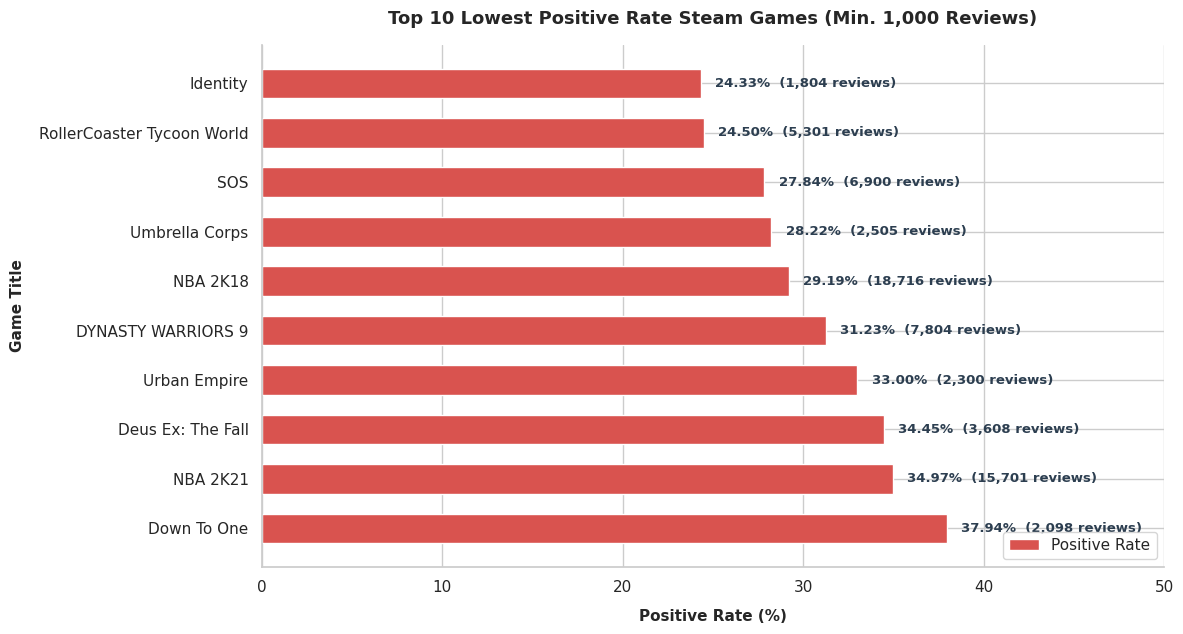

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Dataset
data = {
    "game": [
        "Identity",
        "RollerCoaster Tycoon World",
        "SOS",
        "Umbrella Corps",
        "NBA 2K18",
        "DYNASTY WARRIORS 9",
        "Urban Empire",
        "Deus Ex: The Fall",
        "NBA 2K21",
        "Down To One",
    ],
    "total_reviews": [
        1804,
        5301,
        6900,
        2505,
        18716,
        7804,
        2300,
        3608,
        15701,
        2098,
    ],
    "positive_rate": [
        24.33,
        24.50,
        27.84,
        28.22,
        29.19,
        31.23,
        33.00,
        34.45,
        34.97,
        37.94,
    ],
}

df = pd.DataFrame(data)

# Sort so the lowest rated game appears at the top
df = df.sort_values(by="positive_rate", ascending=False).reset_index(drop=True)

# 2. Setup Plot
plt.figure(figsize=(12, 6.5))
sns.set_theme(style="whitegrid")

# Crimson/Coral tone to indicate negative/low sentiment
BAR_COLOR = "#D9534F"
bars = plt.barh(df["game"], df["positive_rate"], color=BAR_COLOR, height=0.6, label='Positive Rate')

# 3. Add Labels (Positive Rate + Total Reviews)
for bar, total_rev in zip(bars, df["total_reviews"]):
    width = bar.get_width()
    plt.text(
        width + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%  ({total_rev:,} reviews)",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color="#2C3E50",
    )

# 4. Formatting
plt.title(
    "Top 10 Lowest Positive Rate Steam Games (Min. 1,000 Reviews)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Positive Rate (%)", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Game Title", fontsize=11, fontweight="bold", labelpad=10)
plt.xlim(0, 50)  # Capped at 50% for high contrast and label space

plt.legend(loc="lower right", frameon=True)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4480/869553488.py:86: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


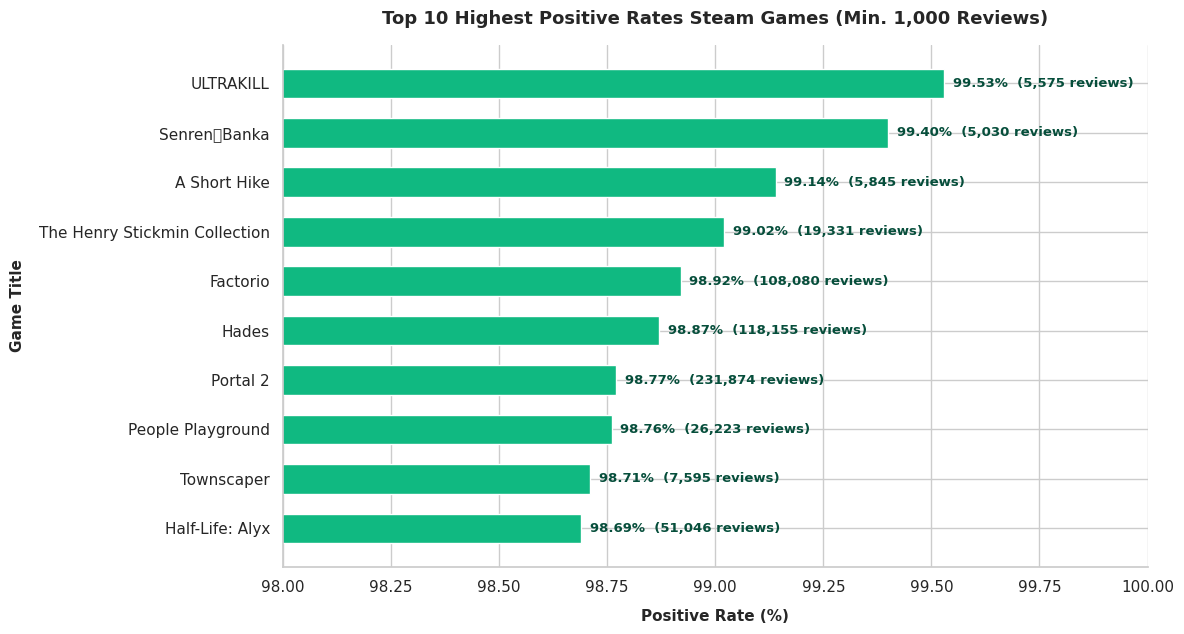

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Dataset
data = {
    "game": [
        "ULTRAKILL",
        "Senren＊Banka",
        "A Short Hike",
        "The Henry Stickmin Collection",
        "Factorio",
        "Hades",
        "Portal 2",
        "People Playground",
        "Townscaper",
        "Half-Life: Alyx",
    ],
    "total_reviews": [
        5575,
        5030,
        5845,
        19331,
        108080,
        118155,
        231874,
        26223,
        7595,
        51046,
    ],
    "positive_rate": [
        99.53,
        99.40,
        99.14,
        99.02,
        98.92,
        98.87,
        98.77,
        98.76,
        98.71,
        98.69,
    ],
}

df = pd.DataFrame(data)

# Sort so the highest rated game appears at the top
df = df.sort_values(by="positive_rate", ascending=True).reset_index(drop=True)

# 2. Setup Figure
plt.figure(figsize=(12, 6.5))
sns.set_theme(style="whitegrid")

# Emerald green theme for overwhelmingly positive sentiment
BAR_COLOR = "#10B981"
bars = plt.barh(df["game"], df["positive_rate"], color=BAR_COLOR, height=0.6)

# 3. Add Precise Labels (Percentage + Volume)
for bar, total_rev in zip(bars, df["total_reviews"]):
    width = bar.get_width()
    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%  ({total_rev:,} reviews)",
        va="center",
        ha="left",
        fontsize=9.5,
        fontweight="bold",
        color="#064E3B",
    )

# 4. Formatting
plt.title(
    "Top 10 Highest Positive Rates Steam Games (Min. 1,000 Reviews)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Positive Rate (%)", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Game Title", fontsize=11, fontweight="bold", labelpad=10)

# Set axis limits to emphasize the top tier (98% to 100%)
plt.xlim(98.0, 100.0)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()